<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [287]:
#Importation de la librairie Pandas
import pandas as pd

In [288]:
#Importation de la librairie plotly express
import plotly.express as px

In [289]:
import numpy as np

In [290]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

In [291]:
pd.set_option("display.max_columns",None)

In [292]:
# Ne pas afficher les alertes liées pd.read_excel (attention pas lié seulement à Excel mais à toutes les librairies)
import warnings
warnings.simplefilter("ignore")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [293]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [294]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [295]:
#Consulter le nombre de colonnes
    ## je ne comprends pas car le nombre de colonnes apparaît à l'étape précédente
#La nature des données dans chacune des colonnes
    #print(df_erp.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [296]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [297]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
 
existence_doublons=df_erp['product_id'].duplicated().any()
print("Doublons détectés :", existence_doublons)

Doublons détectés : False


In [298]:
#Affiche le nombre de valeurs de la colonnes product_id sans doublons
valeurs_uniques = df_erp['product_id'].drop_duplicates().size
print(valeurs_uniques)

825


In [299]:
#Afficher les valeurs distinctes de la colonne stock_status
valeurs_distinctes = df_erp['stock_status'].unique()
print(valeurs_distinctes)
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
    ## Elle est liée à la colonne stock_quantity sans doute par la définition d'un minima ex : <5

['instock' 'outofstock']


In [300]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2'] = np.where(df_erp['stock_quantity'] == 0, 'outofstock', 'instock')
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [301]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [302]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()

821

In [303]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [304]:
#Corriger la ou les données incohérentes
df_erp.loc[398]
df_erp.loc[398, "stock_status"] = "outofstock"
#Vérification en utilisant le même code que plus haut pour afficher les problèmes
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [305]:
###############
## LES PRIX  ##
###############


In [306]:
#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
df_erp.loc[(df_erp['price'].isnull()) | (df_erp['price'] <= 0),:]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


In [307]:
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp['price'].isnull().sum())) 
#Saisir l'instruction manquante dans la fonction format

Nombres d'articles avec un prix non renseigné: 0


In [308]:
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
    ##voir étape 23
    ## Il faut remplacer les valeurs aberrantes

df_erp.loc[df_erp['price'] == -20.0, 'price'] = 20.0
df_erp.loc[df_erp['price'] == -8.0, 'price'] = 8.0
df_erp.loc[df_erp['price'] == -9.1, 'price'] = 9.1
df_erp.loc[
    (df_erp['price'].isnull()) | (df_erp['price'] <= 0),
    :
]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [309]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"

print("Quantité minimum de la colonne stock_quantity: {}".format(df_erp['stock_quantity'].min()))

Quantité minimum de la colonne stock_quantity: -10


In [310]:
#Afficher la quantité maximum de la colonne "stock_quantity"
print("Quantité maximum de la colonne stock_quantity: {}".format(df_erp['stock_quantity'].max()))

Quantité maximum de la colonne stock_quantity: 145


In [311]:
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("Inf.0 {}".format(df_erp[df_erp['stock_quantity'] < 0]))

Inf.0      product_id  onsale_web  price  stock_quantity stock_status  \
449        4973           0   10.0             -10   outofstock   
573        5700           1   44.5              -1   outofstock   

     purchase_price stock_status_2  
449            4.96        instock  
573           22.30        instock  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [312]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp['onsale_web'].unique()
    ## Les "1" correspondents aux ventes réalisées sur le web 

array([1, 0], dtype=int64)

In [313]:
# Que signifient-elles?
print("Les 1 correspondent aux ventes réalisées sur le web") 

Les 1 correspondent aux ventes réalisées sur le web


In [314]:
#Quelles sont les colonnes à conserver selon vous?
print("Toutes sauf stock_status_2")

Toutes sauf stock_status_2


In [315]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp = df_erp.drop('stock_status_2', axis=1)
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [316]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
df_erp.loc[(df_erp['purchase_price'].isnull()),:]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


In [317]:
#Afficher le prix minimum de la colonne "purchase_price"
print("Prix minimum : {}".format(df_erp['purchase_price'].min()))

Prix minimum : 2.74


In [318]:
#Afficher le prix maximum de la colonne "purchase_price"
print("Prix maximum : {}".format(df_erp['purchase_price'].max()))

Prix maximum : 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [319]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))


Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)


In [320]:
#Nombre de caractéristiques
df_web.head()


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,NaN,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,NaN,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,NaN,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,NaN,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [321]:
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
#Consulter le nombre de colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [322]:
#Selon vous, quelles sont les colonnes à conserver ?
print("Uniquement les colonnes contenant des données")

Uniquement les colonnes contenant des données


In [323]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web.dropna(axis=1, how='all', inplace=True)
print("Le tableau comporte désormais {} colonne(s)".format(df_web.shape[1]))

Le tableau comporte désormais 25 colonne(s)


In [324]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
df_web['sku'].unique()

array([11862, 16057, 14692, 16295, 15328, 15471, 16515, 16246, nan, 13572,
       16513, 16585, 16269, 15526, 12869, 15575, 11586, 14338, 15425,
       16560, 15361, 13809, 11587, 15022, 14323, 16342, 16029, 15475,
       13754, 14680, 15875, 9636, 13849, 13662, 16564, 13557, 15429,
       14712, 15032, 15481, 15448, 16580, 15441, 804, 15300, 13958, 16071,
       15678, 13895, 15711, 12882, 16053, 13766, 16247, 12640, 15292,
       15476, 15670, 16189, 16038, 14864, 16044, 15324, 15531, 15953,
       15413, 15733, 14366, 15895, 15892, 16472, 15185, 16010, 15793,
       15849, 12315, 15741, 15934, 15148, 15781, 15659, 15106, 15490,
       14507, 14149, 16307, 13736, 14090, 16037, 15758, 14661, 12587,
       15337, 15489, 15201, 16305, 16131, 13435, 15747, 12203, 14509,
       14768, 16262, 14561, 16505, 15717, 16129, 13460, 15871, 15940,
       11602, 13127, 13520, 15480, 13032, 15436, 15269, 15910, 19821,
       16263, 15138, 15146, 15126, 15482, 16186, 13905, 16540, 15856,
       1567

In [325]:
print("Le fait que le type de la colonne sku soit object signifie qu'il y a des valeurs stockées en txt et en num")

Le fait que le type de la colonne sku soit object signifie qu'il y a des valeurs stockées en txt et en num


In [326]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les

# Vérifie si une valeur est un entier de 5 chiffres (ex: 12345)
def est_sku_valide(sku):
    try:
        # Convertit en int puis en string pour vérifier la longueur
        return sku == int(sku) and len(str(int(sku))) == 5
    except:
        return False

# Appliquer la fonction à la colonne
df_web['sku_valide'] = df_web['sku'].apply(est_sku_valide)

# Afficher les valeurs incorrectes
df_web[~df_web['sku_valide']]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,sku_valide
8,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
33,9636,0,0,0,0.0,0.0,taxable,2.0,2018-03-22 10:44:57,2018-03-22 09:44:57,Whisky,Wemyss Malts Blended Malt Scotch Whisky The Hi...,The Hive est un assemblage de malts du Speysid...,publish,closed,closed,whisky-wemyss-the-hive-12-ans,2020-08-19 17:45:03,2020-08-19 15:45:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
1453,2534,0,0,0,0.0,4.0,NaN,2.0,2018-04-14 11:50:29,2018-04-14 09:50:29,Vin,Marcel Windholtz Eau de Vie de Fraise,NaN,publish,closed,closed,marcel-windholtz-eau-de-vie-de-fraise,2020-08-21 15:45:04,2020-08-21 13:45:04,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,False
1457,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,False
1462,798,0,0,0,0.0,8.0,taxable,2.0,2018-04-14 12:05:09,2018-04-14 10:05:09,Vin,Marcel Windholtz Eau de Vie de Kirsch d'Alsace...,Les eaux de vie naissent d'une subtile alchimi...,publish,closed,closed,marcel-windholtz-eau-de-vie-de-kirsch-dalsace-...,2020-07-23 10:15:03,2020-07-23 08:15:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False


In [327]:
#Identifier les lignes sans code article
lignes_sans_code_article=df_web.loc[(df_web['sku'].isnull()),:]
print(f"Nombre de lignes sans code article : {len(lignes_sans_code_article)}")

print("Numéros de lignes sans code article :", list(lignes_sans_code_article.index))



Nombre de lignes sans code article : 85
Numéros de lignes sans code article : [8, 20, 30, 37, 41, 47, 55, 75, 94, 127, 130, 136, 153, 162, 169, 184, 198, 199, 244, 264, 269, 290, 319, 339, 352, 359, 364, 373, 376, 379, 409, 421, 425, 515, 522, 541, 550, 557, 602, 612, 622, 639, 640, 666, 678, 696, 703, 714, 717, 726, 778, 797, 819, 822, 829, 836, 944, 947, 968, 971, 987, 1005, 1018, 1045, 1065, 1084, 1086, 1087, 1098, 1135, 1137, 1151, 1194, 1231, 1244, 1254, 1263, 1301, 1329, 1332, 1384, 1429, 1432, 1445, 1457]


In [328]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre

In [329]:
#Structure des données dans les autres colonnes quand sku est manquant
lignes_sans_code_article.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   virtual            85 non-null     int64         
 2   downloadable       85 non-null     int64         
 3   rating_count       85 non-null     int64         
 4   average_rating     2 non-null      float64       
 5   total_sales        2 non-null      float64       
 6   tax_status         2 non-null      object        
 7   post_author        2 non-null      float64       
 8   post_date          2 non-null      datetime64[ns]
 9   post_date_gmt      2 non-null      datetime64[ns]
 10  product_type       2 non-null      object        
 11  post_title         2 non-null      object        
 12  post_excerpt       2 non-null      object        
 13  post_status        2 non-null      object        
 14  comment_status 

In [330]:
df_web[df_web['sku'].isnull()][df_web['total_sales'].notnull()]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,sku_valide
1084,NaN,0,0,0,0.0,-56.0,taxable,2.0,2018-08-08 11:23:43,2018-08-08 09:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"<span id=""u1194-83"">Le nez séduit par ses parf...",publish,closed,closed,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False
1087,NaN,0,0,0,0.0,-17.0,taxable,2.0,2018-07-31 12:07:23,2018-07-31 10:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,"Fongeant 2017 explose sur un fruit brillant, p...",publish,closed,closed,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False


Ces 2 articles ont des ventes négatives => traitement confié à l'équipe CRM pour regarder les raisons.
Ces lignes seront exclues pour la suite de l'analyse.

In [331]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
existence_doublons2=df_web['sku'].duplicated().any()
print("Doublons détectés :", existence_doublons2)

Doublons détectés : True


In [332]:
doublons = df_web['sku'].value_counts()
print(doublons[doublons > 1])

sku
11862    2
16324    2
3507     2
14773    2
15967    2
        ..
12639    2
15466    2
15184    2
13078    2
14569    2
Name: count, Length: 714, dtype: int64


In [333]:
#le fichier contient pour le même produit plusieurs lignes car fait référence à une image dans le mail de confirmation et l'autre au produit. 
df_web_final=df_web[df_web['sku'].notnull()]
df_web_final.shape[0]

1428

In [334]:
#Suppression des doublons
df_web_final=df_web_final[df_web_final['post_type']=='product']
df_web_final.shape[0]

714

In [335]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web_sans_code = df_web[df_web['sku'].isnull() | (df_web['sku'] == '')]
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web_sans_code.info()
#3 - Que constatez-vous?

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   virtual            85 non-null     int64         
 2   downloadable       85 non-null     int64         
 3   rating_count       85 non-null     int64         
 4   average_rating     2 non-null      float64       
 5   total_sales        2 non-null      float64       
 6   tax_status         2 non-null      object        
 7   post_author        2 non-null      float64       
 8   post_date          2 non-null      datetime64[ns]
 9   post_date_gmt      2 non-null      datetime64[ns]
 10  product_type       2 non-null      object        
 11  post_title         2 non-null      object        
 12  post_excerpt       2 non-null      object        
 13  post_status        2 non-null      object        
 14  comment_status 

In [336]:
## Constat ??? 

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [337]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))

#Nombre de caractéristiques
    ##Pas sure de savoir ce que l'on entend par caractéristiques
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)


In [338]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [339]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
df_liaison['product_id'].unique().size==df_liaison.shape[0]
    ##si = true alors cela veut dire qu'il n'y a pas de doublon

True

In [340]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
df_liaison['id_web'].unique().size==df_liaison.shape[0]

False

In [341]:
#Avons-nous des articles sans correspondance?
df_liaison_filtré = df_liaison[df_liaison['product_id'].notnull() & df_liaison['id_web'].isnull()]
print (df_liaison_filtré)

    id_web  product_id
19     NaN        4055
49     NaN        4090
50     NaN        4092
119    NaN        4195
131    NaN        4209
..     ...         ...
817    NaN        7196
818    NaN        7200
819    NaN        7201
820    NaN        7203
821    NaN        7204

[91 rows x 2 columns]


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [342]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp, df_liaison,on='product_id',how='outer',indicator=True)

In [343]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
non_match = df_merge[df_merge['_merge'] != 'both']

print(non_match)

Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price, id_web, _merge]
Index: []


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [344]:
#Fusionner les datasets df_merge et df_web
df_merge = df_merge.drop(columns=['_merge'], errors='ignore')

df_merge = pd.merge(df_merge,df_web_final,
                     left_on='id_web',   # nom dans df_liaison
                     right_on='sku',  # nom dans df_web
                     how='outer',
                    indicator=True)

In [345]:
#Avons-nous des lignes sans correspondance?
non_match2 = df_merge[df_merge['_merge'] != 'both']

non_match2.shape

(111, 34)

In [346]:
non_match2[non_match2['_merge']=='left_only']

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,sku_valide,_merge
81,4741,0,12.4,0,outofstock,6.66,12601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
127,5957,0,39.0,0,outofstock,20.75,13577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
139,4289,0,22.8,0,outofstock,11.90,13771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
180,4869,0,17.2,0,outofstock,9.33,14360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
185,5955,0,27.3,0,outofstock,13.68,14377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,7196,0,31.0,55,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
821,7200,0,31.0,6,instock,15.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
822,7201,0,31.0,18,instock,16.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
823,7203,0,45.0,30,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


=> à l'attention des responsables produits : il y a des produits sans identifiants

In [347]:
#Proportion de produits sans correspondance
print(f"Part d'articles sans correspondance:{round((non_match2.shape[0]/df_merge.shape[0])*100,2)} %")

Part d'articles sans correspondance:13.45 %


In [348]:
#Suppression de la colonne 'merge'
df_merge.drop('_merge',axis=1,inplace=True)

In [349]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   product_id         825 non-null    int64         
 1   onsale_web         825 non-null    int64         
 2   price              825 non-null    float64       
 3   stock_quantity     825 non-null    int64         
 4   stock_status       825 non-null    object        
 5   purchase_price     825 non-null    float64       
 6   id_web             734 non-null    object        
 7   sku                714 non-null    object        
 8   virtual            714 non-null    float64       
 9   downloadable       714 non-null    float64       
 10  rating_count       714 non-null    float64       
 11  average_rating     714 non-null    float64       
 12  total_sales        714 non-null    float64       
 13  tax_status         714 non-null    object        
 14  post_autho

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

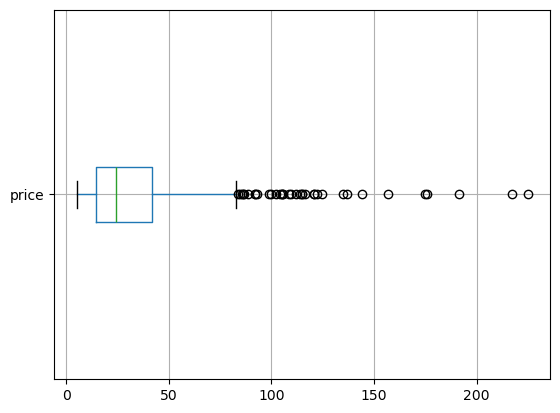

In [350]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
import matplotlib.pyplot as plt

df_merge.boxplot(column='price', vert=False)
plt.show()

In [351]:
#Autre méthode avec plotly express
fig = px.box(df_merge, x="price", orientation="h")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [352]:
##### Calculer la moyenne du prix
moyenne_prix = df_merge["price"].mean()
print("Le prix moyen est : {:.2f}".format(moyenne_prix))

Le prix moyen est : 32.28


In [353]:
#Calculer l'écart-type du prix
ecarttype_prix = df_merge["price"].std()
print("L'écart type du prix est : {:.2f}".format(ecarttype_prix))

L'écart type du prix est : 26.60


In [354]:
#CALCUL DE LA MOYENNE
moyenne_globale=df_merge["price"].mean()
print (moyenne_globale)

32.27763636363637


In [355]:
#calul du zscore
zscore=moyenne_globale/ecarttype_prix
print(zscore)

1.213299198698184


In [356]:
#Calculer le Z-score
df_merge["z_score_price"] = (df_merge["price"] - moyenne_prix) / ecarttype_prix
print(df_merge["z_score_price"].head(5))

0   -0.890030
1    0.327869
2    0.252690
3    1.038310
4   -0.367536
Name: z_score_price, dtype: float64


In [357]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
seuil_prix = moyenne_prix + 3 * ecarttype_prix
print("Le seuil de prix pour un z-score supérieur à 3 est : {:.2f}".format(seuil_prix))

Le seuil de prix pour un z-score supérieur à 3 est : 112.09


In [358]:
#recherche des outlier avec zscore
df_outliers=df_merge[df_merge["price"].apply(lambda x:abs(x-moyenne_prix)/ecarttype_prix)>3]
df_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, 24 to 745
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   product_id         17 non-null     int64         
 1   onsale_web         17 non-null     int64         
 2   price              17 non-null     float64       
 3   stock_quantity     17 non-null     int64         
 4   stock_status       17 non-null     object        
 5   purchase_price     17 non-null     float64       
 6   id_web             16 non-null     object        
 7   sku                16 non-null     object        
 8   virtual            16 non-null     float64       
 9   downloadable       16 non-null     float64       
 10  rating_count       16 non-null     float64       
 11  average_rating     16 non-null     float64       
 12  total_sales        16 non-null     float64       
 13  tax_status         16 non-null     object        
 14  post_author    

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [359]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge['price'].describe()

count    825.000000
mean      32.277636
std       26.603196
min        5.200000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64

In [360]:
#Définir un seuil pour les articles "outliers" en prix
#difference Q3 et Q1 !!!
q1 = df_merge['price'].quantile(0.25)  # 25%
q3 = df_merge['price'].quantile(0.75)  # 75%
Ecart_interquartile = q3-q1

print("L'écart interquartile est de: {:.2f}".format (Ecart_interquartile))


L'écart interquartile est de: 27.50


In [361]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"

borne_inferieure = q1-(1.5*Ecart_interquartile)
borne_superieure=q3+(1.5*Ecart_interquartile)
outliers = df_merge[(df_merge["price"] < borne_inferieure) | (df_merge["price"] > borne_superieure)]
nombre_outliers = len(outliers)
print(f"Nombre d'articles outliers : {nombre_outliers}")

proportion_outliers = nombre_outliers / len(df_merge) * 100
print(f"Proportion d'articles outliers : {proportion_outliers:.2f}%")


Nombre d'articles outliers : 36
Proportion d'articles outliers : 4.36%


In [362]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
print("Pour chaque type de produit, il existe des critères qui font qu'un alcool est plus ou moins coté avec un prix qui varie en fonction.") 
print("Pour l'alcool et notamment le vin, les critères peuvent être le cépage, l'année...")
print("Ces infos sont visibles dans les champs Product_type et Post_title")

Pour chaque type de produit, il existe des critères qui font qu'un alcool est plus ou moins coté avec un prix qui varie en fonction.
Pour l'alcool et notamment le vin, les critères peuvent être le cépage, l'année...
Ces infos sont visibles dans les champs Product_type et Post_title


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [363]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
    ## CA = prix * qté vendue (total_sales)
    # Création de la colonne CA
df_merge["CA"] = df_merge["price"] * df_merge["total_sales"]

In [364]:
    # Affichage des premières lignes pour vérifier
print(df_merge[["price", "total_sales", "CA"]].head())

   price  total_sales     CA
0    8.6         10.0   86.0
1   41.0          6.0  246.0
2   39.0          8.0  312.0
3   59.9          0.0    0.0
4   22.5          8.0  180.0


In [365]:
#Calculer la somme de la colonne "ca_par_article"
CA_total = df_merge["CA"].sum() 
print("Chiffre d'affaires total : {:.2f}".format(CA_total))
print ("Ce résultat correspond au chiffre d'affaire du site web")


Chiffre d'affaires total : 143680.10
Ce résultat correspond au chiffre d'affaire du site web


In [366]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge = df_merge.sort_values(by="CA", ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_merge = df_merge.reset_index(drop=True)
df_merge.index = df_merge.index + 1

#Afficher les 20 premiers articles en CA
df_merge.head(20)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,sku_valide,z_score_price,CA
1,4352,1,225.0,0,outofstock,137.81,15940,15940,0.0,0.0,0.0,0.0,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,7.244331,2475.0
2,5892,1,191.3,98,instock,116.06,14983,14983,0.0,0.0,0.0,0.0,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,5.977566,1147.8
3,4353,1,79.5,127,instock,45.91,12587,12587,0.0,0.0,0.0,0.0,14.0,taxable,2.0,2018-03-02 10:37:26,2018-03-02 09:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,&nbsp;\n\nLe Rosé Grand Cru de la maison Egly-...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,1.775064,1113.0
4,5826,1,41.2,34,instock,21.71,15325,15325,0.0,0.0,0.0,0.0,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,0.335387,824.0
5,6212,1,115.0,16,instock,59.42,13996,13996,0.0,0.0,0.0,0.0,7.0,taxable,2.0,2019-07-25 09:09:17,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,3.109490,805.0
6,5026,1,86.8,101,instock,50.13,13913,13913,0.0,0.0,0.0,0.0,9.0,taxable,2.0,2018-07-18 10:46:30,2018-07-18 08:46:30,Champagne,Champagne Agrapart &amp; Fils Minéral Extra Br...,"Légèrement praliné au nez, nerveux, frais, inc...",publish,closed,closed,champagne-agrapart-fils-mineral-extra-brut-bla...,2020-05-11 14:35:02,2020-05-11 12:35:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,2.049467,781.2
7,5008,1,105.0,12,instock,56.42,11602,11602,0.0,0.0,0.0,0.0,7.0,taxable,2.0,2018-07-17 10:52:41,2018-07-17 08:52:41,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-23 15:35:02,2020-06-23 13:35:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,2.733595,735.0
8,5767,1,175.0,12,instock,90.42,15185,15185,0.0,0.0,0.0,0.0,4.0,taxable,2.0,2019-03-13 14:43:22,2019-03-13 13:43:22,Vin,Camille Giroud Clos de Vougeot 2016,<div>Ce vin provient de vignes âgées de 50 ans...,publish,closed,closed,camille-giroud-clos-de-vougeot-2016,2020-06-11 15:25:04,2020-06-11 13:25:04,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,5.364858,700.0
9,6126,1,135.0,138,instock,80.33,14923,14923,0.0,0.0,0.0,0.0,5.0,taxable,2.0,2019-06-28 17:22:27,2019-06-28 15:22:27,Champagne,Champagne Gosset Célébris Vintage 2007,Une robe somptueuse a la teinte jaune pâle eti...,publish,close

In [367]:
#Graphique en barre des 20 premiers articles avec plotly express
  


In [368]:
px.bar(data_frame=df_merge[:20][::-1], y="post_title", x="CA", orientation="h", title="Palmares des 20 premiers articles en CA")

In [369]:
#présence de doublons !!!!!

df_merge['product_id'].duplicated().any() 
df_merge[df_merge['product_id'].duplicated()]['product_id'].unique()

array([], dtype=int64)

In [370]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge['Part CA']=df_merge['CA']/df_merge['CA'].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge['Cumul_Part_CA'] = df_merge['Part CA'].cumsum()
df_merge.head()


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,sku_valide,z_score_price,CA,Part CA,Cumul_Part_CA
1,4352,1,225.0,0,outofstock,137.81,15940,15940,0.0,0.0,0.0,0.0,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,7.244331,2475.0,0.017226,0.017226
2,5892,1,191.3,98,instock,116.06,14983,14983,0.0,0.0,0.0,0.0,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,5.977566,1147.8,0.007989,0.025214
3,4353,1,79.5,127,instock,45.91,12587,12587,0.0,0.0,0.0,0.0,14.0,taxable,2.0,2018-03-02 10:37:26,2018-03-02 09:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,&nbsp;\n\nLe Rosé Grand Cru de la maison Egly-...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,1.775064,1113.0,0.007746,0.032961
4,5826,1,41.2,34,instock,21.71,15325,15325,0.0,0.0,0.0,0.0,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,0.335387,824.0,0.005735,0.038696
5,6212,1,115.0,16,instock,59.42,13996,13996,0.0,0.0,0.0,0.0,7.0,taxable,2.0,2019-07-25 09:09:17,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,3.109490,805.0,0.005603,0.044298


In [371]:
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA

nb_articles_80 = (df_merge['Cumul_Part_CA'] <= 0.8).sum()

print(f"Nombre d'articles représentant 80% du CA : {nb_articles_80}")

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
catalogue = len(df_merge)
part_nb_articles_80= nb_articles_80/catalogue*100
print(f"Proportion dans catalogue entier du site web: {part_nb_articles_80:.2f}%")



Nombre d'articles représentant 80% du CA : 434
Proportion dans catalogue entier du site web: 52.61%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [372]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge = df_merge.sort_values(by="total_sales", ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_merge = df_merge.reset_index(drop=True)

#Afficher les 20 premiers articles en quantité
df_merge.head(20)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,sku_valide,z_score_price,CA,Part CA,Cumul_Part_CA
0,4867,1,9.9,121,instock,4.86,16148,16148,0.0,0.0,0.0,0.0,36.0,taxable,2.0,2018-05-03 13:20:05,2018-05-03 11:20:05,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,"<div>\n\nUn rosé minéral, fruité et d’une gran...",publish,closed,closed,chateau-de-la-selve-igp-coteaux-de-lardeche-ma...,2020-08-27 09:30:15,2020-08-27 07:30:15,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,-0.841163,356.4,0.002481,0.227993
1,4203,1,9.9,74,instock,5.01,15415,15415,0.0,0.0,0.0,0.0,27.0,taxable,2.0,2018-02-15 14:33:42,2018-02-15 13:33:42,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,Vin de gourmandise à boire sur la fraîcheur po...,publish,closed,closed,mas-laval-igp-pays-herault-pampres-blanc-2018,2020-07-11 16:45:03,2020-07-11 14:45:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,-0.841163,267.3,0.001860,0.402390
2,4275,1,14.9,62,instock,7.78,14864,14864,0.0,0.0,0.0,0.0,24.0,taxable,2.0,2018-02-27 13:33:54,2018-02-27 12:33:54,Vin,I Fabbri Chianti Classico Lamole 2017,Un nez typique de petits fruits rouges. Une bo...,publish,closed,closed,i-fabbri-chianti-classico-lamole-2017,2020-08-22 14:35:02,2020-08-22 12:35:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,-0.653216,357.6,0.002489,0.215575
3,4726,1,12.7,0,outofstock,6.82,14950,14950,0.0,0.0,0.0,0.0,22.0,taxable,2.0,2018-04-18 11:53:51,2018-04-18 09:53:51,Vin,François Baur Pinot Noir Schlittweg 2017,"Un éclat de fruits, de la souplesse, de la ron...",publish,closed,closed,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01,2020-05-06 09:35:01,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,-0.735913,279.4,0.001945,0.368073
4,4647,1,28.5,45,instock,14.14,16525,16525,0.0,0.0,0.0,0.0,22.0,taxable,2.0,2018-04-17 09:28:58,2018-04-17 07:28:58,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,"Sur ce sol très calcaire, la Croix Boissée dél...",publish,closed,closed,bernard-baudry-chinon-rouge-croix-boissee-2017,2020-07-31 09:31:39,2020-07-31 07:31:39,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,-0.141999,627.0,0.004364,0.082242
5,5826,1,41.2,34,instock,21.71,15325,15325,0.0,0.0,0.0,0.0,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,0.335387,824.0,0.005735,0.038696
6,6129,1,5.2,68,instock,2.74,14570,14570,0.0,0.0,0.0,0.0,20.0,taxable,2.0,2019-06-28 18:01:06,2019-06-28 16:01:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,Nez Séduisant et puissant. Bouquet de fleurs j...,publish,closed,closed,moulin-de-gassac-igp-pays-dherault-guilhem-bla...,2020-08-26 15:55:02,2020-08-26 13:55:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,-1.017834,104.0,0.000724,0.952698
7,4220,1,11.6,48,instock,5.75,15758,15758,0.0,0.0,0.0,0.0,18.0,taxable,2.0,2018-02-16 10:54:27,2018-02-16 09:54:27,Vin,Xavier Frissant Touraine Amboise Chenin Les Pi...,"Un Touraine Amboise fin et élégant, un joli ch...",publish,closed,closed,frissant-chenin-pierres-2018,2020-08-27 11:45:02,2020-08-27 09:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,-0.777261,208.8,0.001453,0.579007
8,6569,1,29.0,58,instock,15.28,15705,15705,0.0,0.0,0.0,0.0,17.0,taxable,2.0,2020-01-03 16:39:53,2020-01-03 15:39:53

In [373]:
#Graphique en barre des 20 premiers articles avec plotly express

    ## Création du graphique en barres
px.bar(data_frame=df_merge[:20][::-1],x="total_sales",y="post_title",orientation="h",title="20 premiers articles par quantités vendues")



<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [374]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 
import numpy as np

In [375]:
#Création de la colonne Rotation de stock
df_merge["Rotation_stock"] = (df_merge["stock_quantity"] / df_merge["total_sales"]).round(1)
print(df_merge["Rotation_stock"].describe())

count    692.0
mean       inf
std        NaN
min       -0.1
25%        1.8
50%        2.4
75%        3.1
max        inf
Name: Rotation_stock, dtype: float64


In [376]:
#Remplacement des "inf" par 0
df_merge["Rotation_stock"] = df_merge["Rotation_stock"].replace([np.inf], 0)
print(df_merge["Rotation_stock"].describe())

count    692.000000
mean       2.968786
std        3.466826
min       -0.100000
25%        1.800000
50%        2.400000
75%        3.100000
max       31.200000
Name: Rotation_stock, dtype: float64


In [377]:
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_merge = df_merge.sort_values(by="Rotation_stock", ascending=False)
df_merge = df_merge.reset_index(drop=True)
df_merge.head(20)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,sku_valide,z_score_price,CA,Part CA,Cumul_Part_CA,Rotation_stock
0,4142,1,53.0,125,instock,32.15,11641,11641,0.0,0.0,0.0,0.0,4.0,taxable,2.0,2018-02-13 13:08:44,2018-02-13 12:08:44,Champagne,Champagne Gosset Grand Millésime 2006,"L'attaque est ample, gourmande avec une belle ...",publish,closed,closed,champagne-gosset-grand-millesime-2006,2020-08-20 09:30:03,2020-08-20 07:30:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,0.778943,212.0,0.001476,0.562906,31.2
1,6126,1,135.0,138,instock,80.33,14923,14923,0.0,0.0,0.0,0.0,5.0,taxable,2.0,2019-06-28 17:22:27,2019-06-28 15:22:27,Champagne,Champagne Gosset Célébris Vintage 2007,Une robe somptueuse a la teinte jaune pâle eti...,publish,closed,closed,champagne-gosset-celebris-vintage-2007,2020-08-27 11:45:02,2020-08-27 09:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,3.861279,675.0,0.004698,0.064421,27.6
2,4356,1,51.6,81,instock,31.00,12585,12585,0.0,0.0,0.0,0.0,3.0,taxable,2.0,2018-03-02 10:51:14,2018-03-02 09:51:14,Champagne,Champagne Egly-Ouriet Premier Cru Les Vignes d...,La cuvée Les Vignes de Vrigny est atypique dan...,publish,closed,closed,champagne-egly-ouriet-premier-cru-vrigny,2020-07-30 11:25:02,2020-07-30 09:25:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,0.726317,154.8,0.001077,0.765194,27.0
3,4348,1,59.0,125,instock,34.76,12586,12586,0.0,0.0,0.0,0.0,5.0,taxable,2.0,2018-03-02 09:22:39,2018-03-02 08:22:39,Champagne,Champagne Egly-Ouriet Grand Cru Brut Tradition,"Un Champagne bien équilibré, dense, très éléga...",publish,closed,closed,champagne-egly-ouriet-tradition-grand-cru,2020-08-12 14:00:02,2020-08-12 12:00:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,1.004479,295.0,0.002053,0.332146,25.0
4,4148,1,37.5,71,instock,21.88,1364,1364,0.0,0.0,0.0,0.0,3.0,taxable,2.0,2018-02-13 13:36:44,2018-02-13 12:36:44,Champagne,Champagne Mailly Grand Cru Brut Rosé,Une somptueuse robe rose lumineuse habille cet...,publish,closed,closed,champagne-mailly-grand-cru-brut-rose,2020-08-08 10:45:03,2020-08-08 08:45:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False,0.196306,112.5,0.000783,0.925583,23.7
5,4357,1,39.0,115,instock,22.30,9562,9562,0.0,0.0,0.0,0.0,5.0,taxable,2.0,2018-03-02 10:57:02,2018-03-02 09:57:02,Champagne,Champagne Larmandier-Bernier Latitude,La cuvée Latitude est très équilibrée entre fr...,publish,closed,closed,champagne-larmandier-bernier-latitude,2018-12-28 15:10:04,2018-12-28 14:10:04,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False,0.252690,195.0,0.001357,0.622199,23.0
6,4144,1,49.0,91,instock,27.73,1662,1662,0.0,0.0,0.0,0.0,4.0,taxable,2.0,2018-02-13 13:17:25,2018-02-13 12:17:25,Champagne,Champagne Gosset Grand Rosé,"Le nez exprime sans détour la fraise, dans sa ...",publish,closed,closed,champagne-gosset-grand-rose,2020-08-14 16:45:03,2020-08-14 14:45:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False,0.628585,196.0,0.001364,0.615396,22.8
7,5025,1,112.0,136,instock,68.60,13914,13914,0.0,0.0,0.0,0.0,6.0,taxable,2.0,2018-07-18 10:39:43,2018-07-18 08:39:43,Champagne,Champagne Agrapart &amp; Fils L'Avizoise Extra...,"Une cuvée surprenante, par son amer articulé a...",publish,closed,closed,champagne-agrapart-fils-lavizoise-grand-cru-20...,2020-07-09 17:05:02,2020-07-09 15:05:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,2.996721,672.0,0.004677,0.069098,22.7
8,4350,1,79.5,145,instock,47.30,12588,12588,0.0,0.0,0.0,0.0,7.0,taxable,2.0

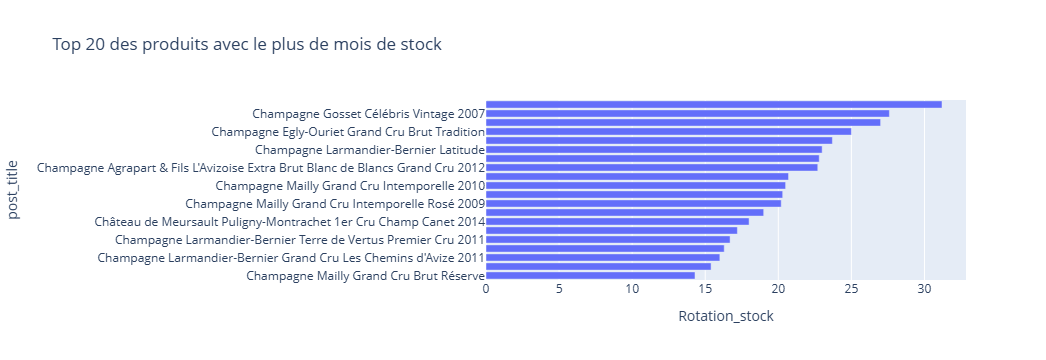

In [378]:
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
px.bar(data_frame=df_merge[:20][::-1], y="post_title", x="Rotation_stock", orientation="h", title="Top 20 des produits avec le plus de mois de stock")

In [379]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge["Valorisation_stock"] = (df_merge["stock_quantity"] * df_merge["price"]).round(2)

In [380]:
#Calculer la somme de la colonne Valorisation des stocks en euros
SUM_Valorisation_stock = df_merge["Valorisation_stock"].sum() 
print("La somme totale de la colonne Valorisation des stocks est : {:.2f}".format(SUM_Valorisation_stock),"€")

La somme totale de la colonne Valorisation des stocks est : 531974.60 €


In [381]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
SUM_Stock_Quantity = df_merge["stock_quantity"].sum() 
print("Le nombre de bouteilles dans notre stock est de : {:d} pièces".format(SUM_Stock_Quantity))

Le nombre de bouteilles dans notre stock est de : 17811 pièces


In [382]:
#Nombre de mois de stock
nb_mois_stock=df_merge["Valorisation_stock"].sum()/df_merge["CA"].sum()
print (f"Nombre de mois de stock : {round(nb_mois_stock,2)}")


Nombre de mois de stock : 3.7


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [383]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_merge['Prix_HT']= df_merge['price'] / (1+0.2)
df_merge.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,sku_valide,z_score_price,CA,Part CA,Cumul_Part_CA,Rotation_stock,Valorisation_stock,Prix_HT
0,4142,1,53.0,125,instock,32.15,11641,11641,0.0,0.0,0.0,0.0,4.0,taxable,2.0,2018-02-13 13:08:44,2018-02-13 12:08:44,Champagne,Champagne Gosset Grand Millésime 2006,"L'attaque est ample, gourmande avec une belle ...",publish,closed,closed,champagne-gosset-grand-millesime-2006,2020-08-20 09:30:03,2020-08-20 07:30:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,0.778943,212.0,0.001476,0.562906,31.2,6625.0,44.166667
1,6126,1,135.0,138,instock,80.33,14923,14923,0.0,0.0,0.0,0.0,5.0,taxable,2.0,2019-06-28 17:22:27,2019-06-28 15:22:27,Champagne,Champagne Gosset Célébris Vintage 2007,Une robe somptueuse a la teinte jaune pâle eti...,publish,closed,closed,champagne-gosset-celebris-vintage-2007,2020-08-27 11:45:02,2020-08-27 09:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,3.861279,675.0,0.004698,0.064421,27.6,18630.0,112.500000
2,4356,1,51.6,81,instock,31.00,12585,12585,0.0,0.0,0.0,0.0,3.0,taxable,2.0,2018-03-02 10:51:14,2018-03-02 09:51:14,Champagne,Champagne Egly-Ouriet Premier Cru Les Vignes d...,La cuvée Les Vignes de Vrigny est atypique dan...,publish,closed,closed,champagne-egly-ouriet-premier-cru-vrigny,2020-07-30 11:25:02,2020-07-30 09:25:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,0.726317,154.8,0.001077,0.765194,27.0,4179.6,43.000000
3,4348,1,59.0,125,instock,34.76,12586,12586,0.0,0.0,0.0,0.0,5.0,taxable,2.0,2018-03-02 09:22:39,2018-03-02 08:22:39,Champagne,Champagne Egly-Ouriet Grand Cru Brut Tradition,"Un Champagne bien équilibré, dense, très éléga...",publish,closed,closed,champagne-egly-ouriet-tradition-grand-cru,2020-08-12 14:00:02,2020-08-12 12:00:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,1.004479,295.0,0.002053,0.332146,25.0,7375.0,49.166667
4,4148,1,37.5,71,instock,21.88,1364,1364,0.0,0.0,0.0,0.0,3.0,taxable,2.0,2018-02-13 13:36:44,2018-02-13 12:36:44,Champagne,Champagne Mailly Grand Cru Brut Rosé,Une somptueuse robe rose lumineuse habille cet...,publish,closed,closed,champagne-mailly-grand-cru-brut-rose,2020-08-08 10:45:03,2020-08-08 08:45:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,False,0.196306,112.5,0.000783,0.925583,23.7,2662.5,31.250000


In [384]:
#Création de la colonne Taux de marge
df_merge['Taux_marge'] = (df_merge['Prix_HT']-df_merge['purchase_price'])/df_merge['Prix_HT']

#Afficher le prix minimum de la colonne "taux_marge"
Min_taux_marge=df_merge['Taux_marge'].min()
print (f"Valeur minimale du taux de marge: {round(Min_taux_marge,2)}")

#Afficher le prix maximum de la colonne "taux_marge"
Max_taux_marge=df_merge['Taux_marge'].max()
print (f"Valeur maximale du taux de marge: {round(Max_taux_marge,2)}")

Valeur minimale du taux de marge: -6.35
Valeur maximale du taux de marge: 0.48


In [385]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_merge.loc[df_merge['Taux_marge']<0,:]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,sku_valide,z_score_price,CA,Part CA,Cumul_Part_CA,Rotation_stock,Valorisation_stock,Prix_HT,Taux_marge
690,4355,1,12.65,97,instock,77.48,12589,12589,0.0,0.0,0.0,0.0,0.0,taxable,2.0,2018-03-02 10:46:10,2018-03-02 09:46:10,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,Le Blanc de Noirs représente le meilleur du sa...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-blanc-de-...,2020-08-13 10:15:02,2020-08-13 08:15:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,True,-0.737792,0.0,0.0,1.0,0.0,1227.05,10.541667,-6.349881
726,4864,0,8.30,0,outofstock,9.99,15154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.901307,NaN,NaN,NaN,NaN,0.00,6.916667,-0.444337
770,6324,0,92.00,18,instock,99.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.244932,NaN,NaN,NaN,NaN,1656.00,76.666667,-0.291304
820,7196,0,31.00,55,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.048026,NaN,NaN,NaN,NaN,1705.00,25.833333,-0.207742


In [386]:
#Création d'un dataframe avec les taux positifs
df_tx_positif = df_merge[df_merge['Taux_marge']>=0]

#Afficher le prix minimum de la colonne "taux_marge"
Min_taux_marge_pos=df_tx_positif['Taux_marge'].min()
print (f"Valeur minimale du taux de marge: {round(Min_taux_marge_pos,2)}")

#Afficher le prix maximum de la colonne "taux_marge"
Max_taux_marge_pos=df_tx_positif['Taux_marge'].max()
print (f"Valeur maximale du taux de marge: {round(Max_taux_marge_pos,2)}")

Valeur minimale du taux de marge: 0.23
Valeur maximale du taux de marge: 0.48


In [387]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_tx_moyen=df_tx_positif.groupby('product_type')['Taux_marge'].mean().reset_index()
print (df_tx_moyen)


    product_type  Taux_marge
0      Champagne    0.284885
1         Cognac    0.450676
2            Gin    0.428000
3  Huile d'olive    0.249982
4            Vin    0.380123
5         Whisky    0.449189


In [388]:
#Affichage dans un graphique du taux de marge par type de produit
px.bar(data_frame=df_tx_moyen[:20][::-1],
       x="Taux_marge",
       y="product_type",
       orientation="h",
       title="Taux de marge par type de produit",
       text="Taux_marge")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

In [389]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns


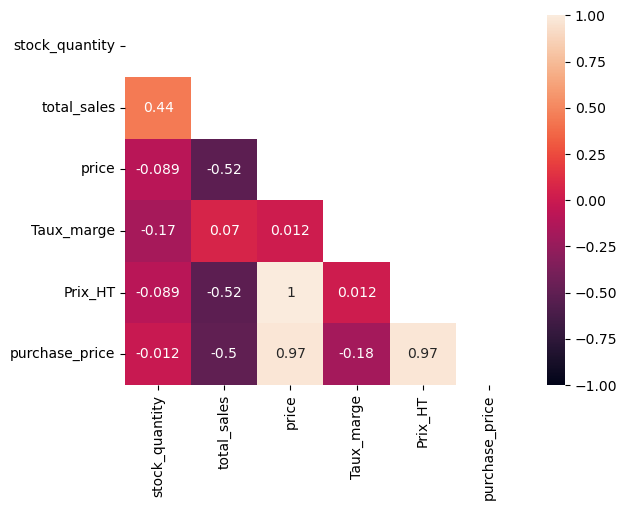

In [390]:
#Création d'une heatmap de corrélation avec les variables stock, sales et price
#On peut également créer un mask pour n'afficher qu'une demi heatmap

# Création du mask
mask = np.triu(np.ones_like(df_merge[["stock_quantity", "total_sales", "price", "Taux_marge", "Prix_HT", "purchase_price"]].corr()))

# Création de la heatmap
sns.heatmap(df_merge[["stock_quantity", "total_sales", "price", "Taux_marge", "Prix_HT", "purchase_price"]].corr(),vmin=-1, vmax=1, annot=True, mask=mask)
plt.show()



In [391]:
#Que peut-on conclure des corrélations ?

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [392]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  

df_merge.to_excel(r"C:\Users\Maela COLLONG\OneDrive - CATALYS CONSEIL\FORMATION DATA\Module 6\OPTION A\OPTION A_Fichier Excel.xlsx", index=False)